# Analisis de indicadores del Banco Mundial (2010-2024)

**Paises:** Estados Unidos (USA), Alemania (DEU), China (CHN), Venezuela (VEN), Australia (AUS)

**Indicadores:**
- `SP.POP.TOTL` - Poblacion total
- `NY.GDP.PCAP.CD` - PIB per capita (USD actuales)
- `EN.GHG.CO2.PC.CE.AR5` - Emisiones de CO2 per capita (t CO2e, excl. uso de suelo)
- `SP.DYN.LE00.IN` - Esperanza de vida al nacer (anios)

Flujo: consumir la API del Banco Mundial, transformar a DataFrames, analizar y graficar, guardar en SQLite.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

pd.set_option("display.max_columns", None)

## Paso 1 y 2: Configuracion y exploracion de la API

Definimos los paises e indicadores a consultar, y revisamos la estructura de la respuesta antes de automatizar la descarga.

In [2]:
PAISES = {
    "USA": "Estados Unidos",
    "DEU": "Alemania",
    "CHN": "China",
    "VEN": "Venezuela",
    "AUS": "Australia",
}

INDICADORES = {
    "SP.POP.TOTL": "Poblacion total",
    "NY.GDP.PCAP.CD": "PIB per capita (USD)",
    "EN.GHG.CO2.PC.CE.AR5": "Emisiones CO2 per capita (t CO2e, excl. uso de suelo)",
    "SP.DYN.LE00.IN": "Esperanza de vida (anios)",
}

BASE_URL = "https://api.worldbank.org/v2"

In [3]:
# Exploramos la estructura de una respuesta antes de automatizar
url = f"{BASE_URL}/country/USA/indicator/SP.POP.TOTL"
params = {"format": "json", "date": "2020:2024", "per_page": 10}
resp = requests.get(url, params=params, timeout=30)
resp.raise_for_status()
payload = resp.json()

print("Metadatos (payload[0]):", payload[0])
print("Primer registro (payload[1][0]):", payload[1][0])

Metadatos (payload[0]): {'page': 1, 'pages': 1, 'per_page': 10, 'total': 5, 'sourceid': '2', 'lastupdated': '2026-07-13'}
Primer registro (payload[1][0]): {'indicator': {'id': 'SP.POP.TOTL', 'value': 'Population, total'}, 'country': {'id': 'US', 'value': 'United States'}, 'countryiso3code': 'USA', 'date': '2024', 'value': 340003797, 'unit': '', 'obs_status': '', 'decimal': 0}


## Paso 3: Descargar los datos

Funcion que consulta la API para un pais e indicador, manejando paginacion, y luego recorremos los 5 paises y los 4 indicadores (20 llamadas en total).

In [4]:
def obtener_indicador(pais_iso3, indicador, anio_inicio=2010, anio_fin=2024):
    """
    Consulta la API del Banco Mundial para un pais e indicador dados,
    manejando paginacion, y devuelve una lista de registros
    {country, year, value}.
    """
    registros = []
    pagina = 1
    while True:
        url = f"{BASE_URL}/country/{pais_iso3}/indicator/{indicador}"
        params = {
            "format": "json",
            "date": f"{anio_inicio}:{anio_fin}",
            "per_page": 100,
            "page": pagina,
        }
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        payload = response.json()

        metadata = payload[0]
        datos_pagina = payload[1] or []

        for item in datos_pagina:
            registros.append({
                "country": pais_iso3,
                "year": item["date"],
                "value": item["value"],
            })

        if pagina >= metadata["pages"]:
            break
        pagina += 1

    return registros

In [5]:
datos_crudos = {}  # indicador -> lista de registros de todos los paises

for codigo_indicador in INDICADORES:
    registros_indicador = []
    for iso3 in PAISES:
        registros_indicador.extend(obtener_indicador(iso3, codigo_indicador))
    datos_crudos[codigo_indicador] = registros_indicador
    print(f"{codigo_indicador}: {len(registros_indicador)} registros descargados")

SP.POP.TOTL: 75 registros descargados
NY.GDP.PCAP.CD: 75 registros descargados
EN.GHG.CO2.PC.CE.AR5: 75 registros descargados
SP.DYN.LE00.IN: 75 registros descargados


## Paso 4: Transformar a DataFrames

Un DataFrame por indicador, con limpieza minima: quitar filas con `value` nulo, convertir `year` a entero y `value` a numerico.

In [6]:
dataframes = {}

for codigo_indicador, registros in datos_crudos.items():
    df = pd.DataFrame(registros)
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"])
    df["country_name"] = df["country"].map(PAISES)
    dataframes[codigo_indicador] = df.sort_values(["country", "year"]).reset_index(drop=True)

dataframes["NY.GDP.PCAP.CD"].head()

,country,year,value,country_name
0,AUS,2010,52313.893904,Australia
1,AUS,2011,62799.389502,Australia
2,AUS,2012,68301.440251,Australia
3,AUS,2013,68476.678850,Australia
4,AUS,2014,62817.206175,Australia


## Paso 5: Analisis y visualizacion

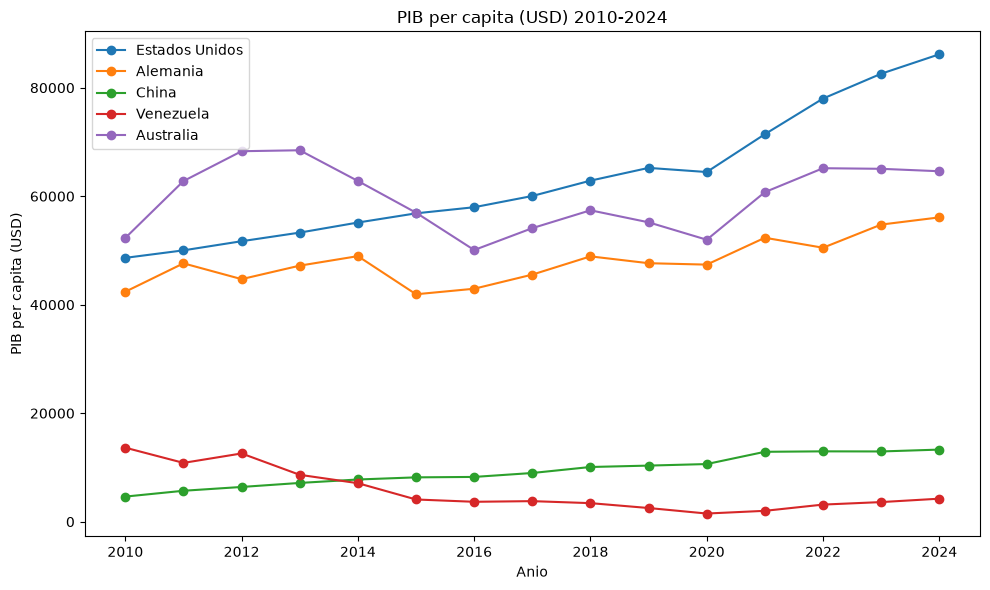

In [7]:
df_pib = dataframes["NY.GDP.PCAP.CD"]

plt.figure(figsize=(10, 6))
for iso3, nombre in PAISES.items():
    sub = df_pib[df_pib["country"] == iso3]
    plt.plot(sub["year"], sub["value"], marker="o", label=nombre)

plt.title("PIB per capita (USD) 2010-2024")
plt.xlabel("Anio")
plt.ylabel("PIB per capita (USD)")
plt.legend()
plt.tight_layout()
plt.show()

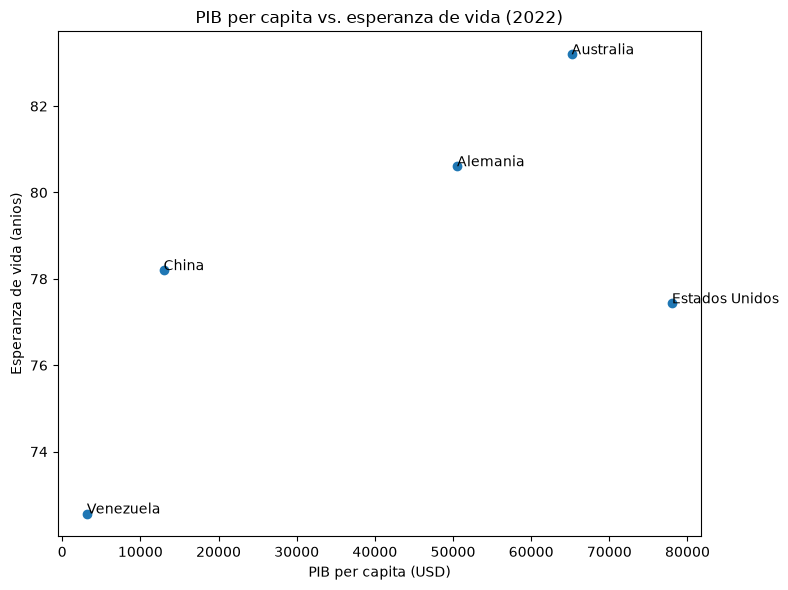

In [8]:
anio_referencia = 2022

df_pib_anio = dataframes["NY.GDP.PCAP.CD"]
df_pib_anio = df_pib_anio[df_pib_anio["year"] == anio_referencia][["country", "value"]].rename(columns={"value": "pib_per_capita"})

df_vida_anio = dataframes["SP.DYN.LE00.IN"]
df_vida_anio = df_vida_anio[df_vida_anio["year"] == anio_referencia][["country", "value"]].rename(columns={"value": "esperanza_vida"})

comparacion = df_pib_anio.merge(df_vida_anio, on="country")
comparacion["country_name"] = comparacion["country"].map(PAISES)

plt.figure(figsize=(8, 6))
plt.scatter(comparacion["pib_per_capita"], comparacion["esperanza_vida"])
for _, fila in comparacion.iterrows():
    plt.annotate(fila["country_name"], (fila["pib_per_capita"], fila["esperanza_vida"]))

plt.title(f"PIB per capita vs. esperanza de vida ({anio_referencia})")
plt.xlabel("PIB per capita (USD)")
plt.ylabel("Esperanza de vida (anios)")
plt.tight_layout()
plt.show()

### Hallazgos

Al comparar los cinco paises a lo largo del periodo 2010-2024 aparecen patrones que van mas alla de lo que muestra cada indicador por separado.

El caso mas llamativo es Venezuela: mientras los otros cuatro paises mantuvieron o mejoraron su PIB per capita, el de Venezuela cayo un 69% (de $13.646 en 2010 a $4.244 en 2024), pasando de un nivel medio a ser el mas bajo del grupo. Esta caida economica coincide con la unica perdida de poblacion del dataset (-1.4%, de 28.8 a 28.4 millones de habitantes), lo que sugiere un vinculo entre la crisis economica del pais y procesos migratorios que redujeron su poblacion en lugar de hacerla crecer como en el resto de los casos.

En el otro extremo esta China, que casi triplico su PIB per capita (+187%, de $4.629 a $13.293), reflejando su despegue economico de las ultimas decadas. Pero ese crecimiento tuvo un costo ambiental: es el unico pais del grupo cuyas emisiones de CO2 per capita subieron (+37%, de 6.81 a 9.32 toneladas), mientras que Alemania, Australia y Estados Unidos las redujeron entre 24% y 30% en el mismo periodo. Esto muestra que el crecimiento economico acelerado y la reduccion de emisiones no siempre van de la mano: los paises ya industrializados pueden permitirse bajar sus emisiones porque ya alcanzaron un nivel de desarrollo alto, mientras que China todavia esta en la etapa de industrializacion que tipicamente aumenta las emisiones per capita.

El grafico de dispersion de PIB per capita vs esperanza de vida (2022) muestra una correlacion positiva moderada (0.63): en general, a mayor PIB per capita, mayor esperanza de vida. Sin embargo, Estados Unidos rompe claramente esa tendencia: con el PIB per capita mas alto del grupo ($78.009), tiene una esperanza de vida menor (77.4 anios) que Alemania (80.6 anios) y Australia (83.2 anios), paises con ingresos per capita bastante mas bajos. Esto sugiere que el ingreso promedio por si solo no garantiza mejores resultados de salud poblacional, y que factores como el acceso al sistema de salud o la desigualdad interna pueden pesar tanto o mas que el nivel de riqueza agregado del pais.

En conjunto, estos datos muestran que el crecimiento economico, el crecimiento poblacional, las emisiones de CO2 y la esperanza de vida no se mueven siempre en la misma direccion, y que cada pais sigue una trayectoria propia moldeada por su contexto politico y social particular.

## Paso 6: Cargar resultados a la base de datos SQL

Usamos SQLite con SQLAlchemy: una tabla por indicador, reemplazando el contenido si ya existe.

In [9]:
engine = create_engine("sqlite:///world_bank_analysis.db")

TABLAS = {
    "SP.POP.TOTL": "indicator_population_total",
    "NY.GDP.PCAP.CD": "indicator_gdp_per_capita",
    "EN.GHG.CO2.PC.CE.AR5": "indicator_co2_per_capita",
    "SP.DYN.LE00.IN": "indicator_life_expectancy",
}

for codigo_indicador, nombre_tabla in TABLAS.items():
    dataframes[codigo_indicador].to_sql(nombre_tabla, engine, if_exists="replace", index=False)
    print(f"Guardada tabla '{nombre_tabla}' ({len(dataframes[codigo_indicador])} filas)")

Guardada tabla 'indicator_population_total' (75 filas)
Guardada tabla 'indicator_gdp_per_capita' (75 filas)
Guardada tabla 'indicator_co2_per_capita' (75 filas)
Guardada tabla 'indicator_life_expectancy' (75 filas)


In [10]:
verificacion = pd.read_sql("SELECT * FROM indicator_gdp_per_capita LIMIT 5", engine)
verificacion

,country,year,value,country_name
0,AUS,2010,52313.893904,Australia
1,AUS,2011,62799.389502,Australia
2,AUS,2012,68301.440251,Australia
3,AUS,2013,68476.678850,Australia
4,AUS,2014,62817.206175,Australia
